In [60]:
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from difflib import SequenceMatcher

import re

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# 1. load data
df = pd.read_csv("/Users/zphilipp/Downloads/bq-results-20250730-130837-1753881075041.csv")

# 2. agg
grouped = df.groupby(['searchString', 'suggestionView'], as_index=False).agg({
    'searchCount': 'sum',
    'suggestionClicks': 'sum',
    'dealClicks': 'sum',
    'dealPurchased': 'sum'
})

In [62]:
def compute_label(row):
    if row.get('is_exact_match', 0) == 1:
        return 1.0

    ctr = row['suggestionClicks'] / row['searchCount'] if row['searchCount'] > 0 else 0
    cvr = row['dealPurchased'] / row['suggestionClicks'] if row['suggestionClicks'] > 0 else 0

    label = .5 * ctr + 1 * cvr

    # Bonus if order 
    if row['dealPurchased'] > 0:
        label += 0.25
        
    if row.get('starts_with_same_word', 0) == 1:
        s1 = str(row['searchString']).lower()
        s2 = str(row['suggestionView']).lower()

        # count number of matched chars
        count = 0
        for ch1, ch2 in zip(s1, s2):
            if ch1 == ch2:
                count += 1
            else:
                break

        # Bonus for each additional letter beyond the first one, e.g., 0.02.
        bonus_per_char = 0.1
        bonus = max(0, (count - 1) * bonus_per_char)
        label += bonus

    return min(label, 1.0)
    
def add_text_features(df):
    
    def char_similarity(a, b):
        return SequenceMatcher(None, a.lower(), b.lower()).ratio()
    
    # Word overlap
    def word_overlap_count(str1, str2):
        set1 = set(str(str1).lower().split())
        set2 = set(str(str2).lower().split())
        return len(set1 & set2)

    # Features
    df['text_similarity'] = df.apply(lambda row: char_similarity(row['searchString'], row['suggestionView']), axis=1)
    df['length_diff'] = df.apply(lambda row: abs(len(str(row['searchString'])) - len(str(row['suggestionView']))), axis=1)
    df['word_overlap_count'] = df.apply(lambda row: word_overlap_count(row['searchString'], row['suggestionView']), axis=1)
    df['starts_with_same_word'] = df.apply(
        lambda row: int(str(row['searchString']).split()[0].lower() == str(row['suggestionView']).split()[0].lower())
        if row['searchString'] and row['suggestionView'] else 0, axis=1)
    df['is_exact_match'] = df.apply(lambda row: int(str(row['searchString']).strip().lower() == str(row['suggestionView']).strip().lower()), axis=1)
    df['is_suggest_in_search'] = df.apply(lambda row: int(str(row['suggestionView']).lower() in str(row['searchString']).lower()), axis=1)
    df['is_search_in_suggest'] = df.apply(lambda row: int(str(row['searchString']).lower() in str(row['suggestionView']).lower()), axis=1)
    df['is_prefix_match'] = df.apply(lambda row: int(
        str(row['searchString']).lower().startswith(str(row['suggestionView']).lower()) or
        str(row['suggestionView']).lower().startswith(str(row['searchString']).lower())), axis=1)

    return df

grouped = add_text_features(grouped)
grouped['label'] = grouped.apply(compute_label, axis=1)

In [63]:
grouped.query("label > 0.2 and label < 0.3").head(1000)

,searchString,suggestionView,searchCount,suggestionClicks,dealClicks,dealPurchased,text_similarity,length_diff,word_overlap_count,starts_with_same_word,is_exact_match,is_suggest_in_search,is_search_in_suggest,is_prefix_match,label
5076,ac,ac tune up,3,1,0,0,0.333333,8,1,1,0,0,1,1,0.266667
5083,ac,activities for kids,2,1,1,0,0.190476,17,0,0,0,0,1,1,0.250000
5390,acc,accupuncture,8,4,1,0,0.400000,9,0,0,0,0,1,1,0.250000
5462,accupunctu,accupuncture,2,1,0,0,0.909091,2,0,0,0,0,1,1,0.250000
5463,accupunctu,acupuncture,2,1,1,0,0.857143,1,0,0,0,0,0,0,0.250000
5790,acryl,acrylic nails,2,1,0,0,0.555556,8,0,0,0,0,1,1,0.250000
5868,acti,activities,14,6,6,0,0.571429,6,0,0,0,0,1,1,0.214286
5927,activ,kids activities,2,1,1,0,0.500000,10,0,0,0,0,1,0,0.250000
6061,activity,couples activities,2,1,1,0,0.538462,10,0,0,0,0,0,0,0.250000
6070,activity,kid activities,2,1,2,0,0.608696,5,0,0,0,0,0,0,0.250000


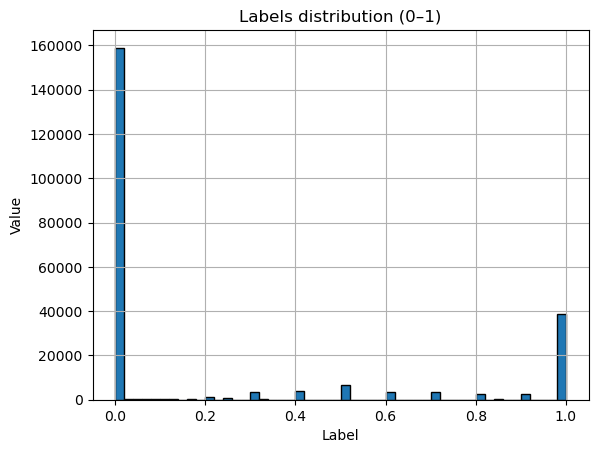

In [64]:
plt.hist(grouped['label'], bins=50, edgecolor='black')
plt.title("Labels distribution (0–1)")
plt.xlabel("Label")
plt.ylabel("Value")
plt.grid(True)
plt.show()

In [65]:
# prepare labeled data for training
X = grouped.drop(columns=['searchString', 'suggestionView', 'label'])

y = grouped['label']

# data split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# model train
model = GradientBoostingRegressor()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Matrics Root mean square error
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"R² score: {r2:.4f}")

RMSE: 0.0564
R² score: 0.9794


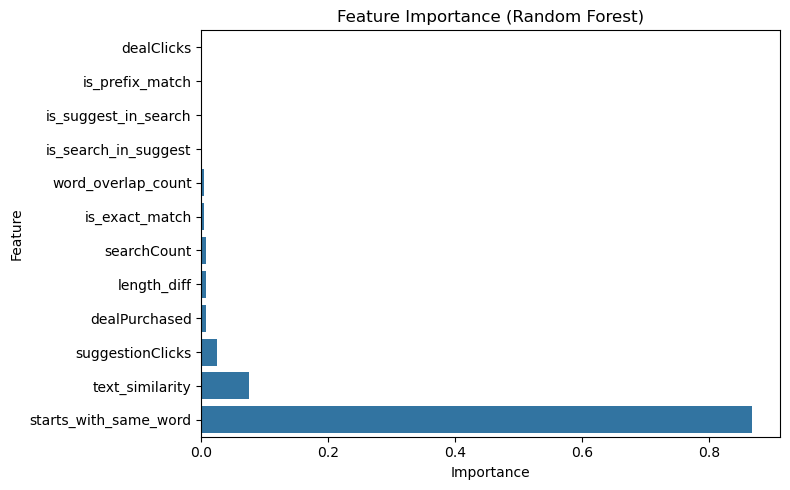

In [66]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=True)

plt.figure(figsize=(8, 5))
sns.barplot(x="Importance", y="Feature", data=importance_df)
plt.title("Feature Importance (Random Forest)")
plt.tight_layout()
plt.show()

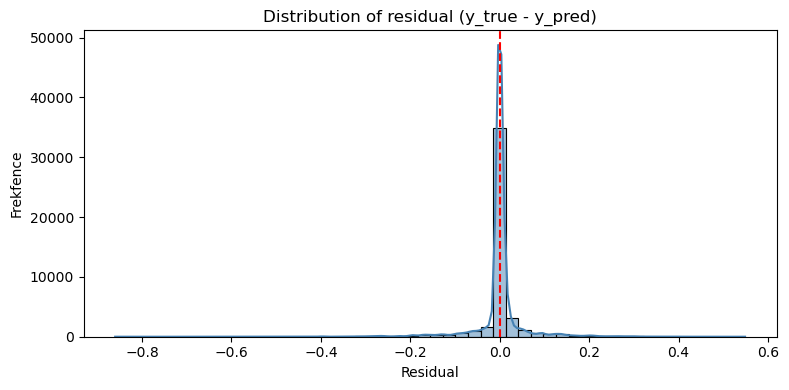

In [67]:
# residuals
y_pred = model.predict(X_test)
residuals = y_test - y_pred

# Histogram of residuals
plt.figure(figsize=(8, 4))
sns.histplot(residuals, bins=50, kde=True, color='steelblue')
plt.title('Distribution of residual (y_true - y_pred)')
plt.xlabel('Residual')
plt.ylabel('Frekfence')
plt.axvline(0, color='red', linestyle='--')
plt.tight_layout()
plt.show()

In [78]:
# Prediction
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Metrics
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
r2_train = r2_score(y_train, y_train_pred)

rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2_test = r2_score(y_test, y_test_pred)

# RMSE (Root Mean Squared Error)
# Meaning of Metrics
# Metric = Meaning
# RMSE (Root Mean Squared Error) = Measures the average magnitude of the prediction errors. It’s the square root of the average of squared differences between predicted and actual values. Lower RMSE means better performance.
# R² (R-squared / Coefficient of Determination)	= Indicates how well the model explains the variability of the target variable. Ranges from 0 to 1, where 1 means perfect fit. Higher values indicate that the model captures more of the variance.

# For example
# RMSE ~ 0.055 → Model predictions are, on average, only 0.055 units off from the true label (on a scale from 0 to 1), which is very small — good accuracy.
# R² ~ 0.98 → Model explains 98% of the variance in the target values — an excellent fit.
# The similarity between train and test results indicates good generalization, i.e., no overfitting.
print(f"Train RMSE: {rmse_train:.4f}, R²: {r2_train:.4f}")
print(f"Test  RMSE: {rmse_test:.4f}, R²: {r2_test:.4f}")

Train RMSE: 0.0553, R²: 0.9802
Test  RMSE: 0.0564, R²: 0.9794


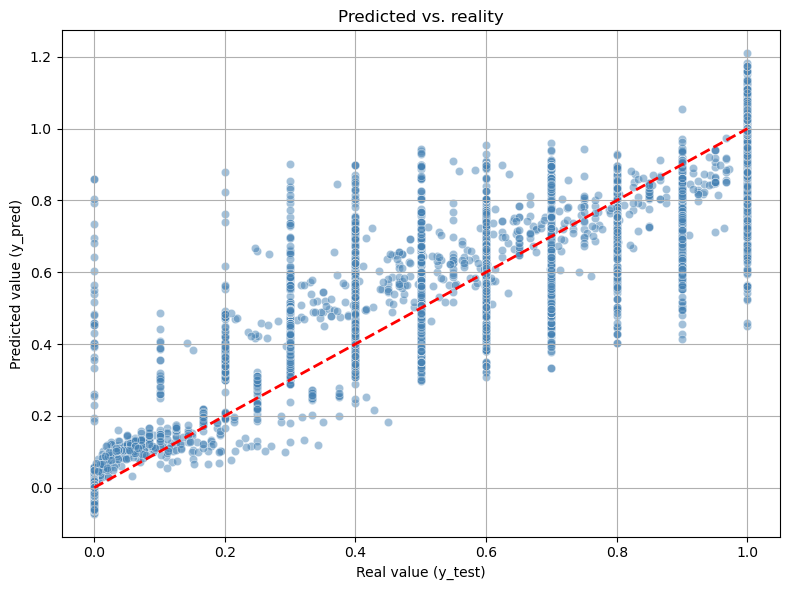

In [69]:
# Prediction
y_pred = model.predict(X_test)

# Scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5, color='steelblue')

# Ideal linie: y = x
plt.plot([0, 1], [0, 1], 'r--', linewidth=2)

plt.xlabel('Real value (y_test)')
plt.ylabel('Predicted value (y_pred)')
plt.title('Predicted vs. reality')
plt.grid(True)
plt.tight_layout()
plt.show()

### Example of prediction

In [70]:
new_data = pd.DataFrame([{
    'searchString': '360 chi',
    'suggestionView': '360 chicago',
    'searchCount': 1,
    'suggestionClicks': 1,
    'dealClicks': 1,
    'dealPurchased': 1
}])
new_data = add_text_features(new_data)

In [71]:
feature_cols = [
    'searchCount', 'suggestionClicks', 'dealClicks', 'dealPurchased',
    'text_similarity', 'length_diff', 'word_overlap_count',
    'starts_with_same_word', 'is_exact_match', 'is_suggest_in_search',
    'is_search_in_suggest', 'is_prefix_match'
]
X_new = new_data[feature_cols]

In [72]:
predicted_label = model.predict(X_new)[0]

In [73]:
print(f"Predicted label for '{new_data.iloc[0]['searchString']}' vs '{new_data.iloc[0]['suggestionView']}': {predicted_label:.4f}")

Predicted label for '360 chi' vs '360 chicago': 0.9071
